# Import required libraries

In [39]:
import operator
import functools
import pandas as pd
from PIL import Image
from pydantic import BaseModel

# typing decorators
from IPython.display import Markdown, display
from typing import List, Tuple, Dict, Any, Sequence, Annotated, Literal
from typing_extensions import TypedDict

# langchain packages
from langchain_core.messages import HumanMessage
from langchain_core.messages import BaseMessage
from langchain_core.tools import tool
from langchain_core.output_parsers import (StrOutputParser, 
                                            JsonOutputParser)
from langchain_core.prompts import ChatPromptTemplate


# langgraph packages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import START, END, StateGraph, MessagesState
from langgraph.prebuilt import ToolNode, create_react_agent

# Transformer packages
from transformers import (AutoModelForImageClassification, 
                            AutoImageProcessor)


# Load custom defined packages
from models import (GenderPredictionFromPreTrainedModel, 
                    AgePredictionForPretrainedModel)

# Getting Random Patient Details

In [40]:
# Load patient dataset
updated_patient_df = pd.read_csv('datasets/input/processed/updated_patient_df.csv')
updated_patient_df.drop('Unnamed: 0', axis = 1, inplace = True)
updated_patient_df.head(10)


# Pick a Random Patient: A female between 20 and 29 and with Pneumonia as Positive 
selected_patients = updated_patient_df[
    (updated_patient_df['Gender'] == 'Female') & \
        (updated_patient_df['Age'].between(20, 29)) & \
            (updated_patient_df['Difficulty Breathing'] == 'Yes') & \
                (updated_patient_df['Outcome Variable'] == 'Positive')]

# Choosing first patient details as our subject
selected_patients = (selected_patients
                                .reset_index(drop = True)
                                .iloc[0, :])

selected_patients


Disease                     Influenza
Fever                             Yes
Cough                             Yes
Fatigue                           Yes
Difficulty Breathing              Yes
Age                                25
Gender                         Female
Blood Pressure                 Normal
Cholesterol Level              Normal
Outcome Variable             Positive
First_Name                     Amrita
Last_Name                        Nair
Patient_ID              PAT1000000007
Full_Name                 Amrita_Nair
Name: 0, dtype: object

# Agent

### 1.1 Define Patient Verification Tool

In [41]:
def patient_verification_tool(image_path, updated_patient_df, selected_patient_data):
    from PIL import Image
    # Gender Prediction
    image = Image.open(image_path)

    # Load PreTrained Model - Gender
    gender_processor = AutoImageProcessor.from_pretrained("rizvandwiki/gender-classification")
    gender_model = AutoModelForImageClassification.from_pretrained("rizvandwiki/gender-classification")

    # Generate Gender Classification Predictions 
    predicted_gender = GenderPredictionFromPreTrainedModel(image, gender_processor, gender_model)

    # Load PreTrained Model - Age Group Prediction
    age_processor = AutoImageProcessor.from_pretrained("nateraw/vit-age-classifier")
    age_model = AutoModelForImageClassification.from_pretrained("nateraw/vit-age-classifier")

    # Generate Image Classification Predictions
    predicted_age_group = AgePredictionForPretrainedModel(image, age_processor, age_model)


    # Parse the age range string (e.g .. 20-29)
    age_min, age_max = map(int, predicted_age_group.split('-'))
    print(f"Age Group Prediction: Minimum : {age_min} and Maximum: {age_max}")

    # Now, we have to check if the respective age group of the customer and gender 
    # is matching to what we have predicted using the pretrained model
    updated_patient_df['Gender'] = updated_patient_df['Gender'].apply(lambda x : x.lower())
    matching_records = updated_patient_df[
                (updated_patient_df["First_Name"]== selected_patient_data["First_Name"]) &
                (updated_patient_df["Last_Name"] == selected_patient_data["Last_Name"]) &
                (updated_patient_df["Patient_ID"] == selected_patient_data["Patient_ID"]) &
                (updated_patient_df["Gender"] == predicted_gender) &
                (updated_patient_df["Age"].between(age_min, age_max))
    ]

    if matching_records.empty:
        patient_verification = "Patient ID is not verified"
    else:
        patient_verification = f"""Verification successfull.
                                Patient is: {selected_patient_data["First_Name"]} {selected_patient_data["Last_Name"]}
                                with ID : {selected_patient_data["Patient_ID"]} 
                                which is {predicted_gender} in age group of {predicted_age_group} can proceed to the physician
        """

    return patient_verification


front_desk_verification_status = patient_verification_tool(
    image_path = 'datasets/FaceID/image1.png', 
    updated_patient_df = updated_patient_df, 
    selected_patient_data = selected_patients
)

display(Markdown(front_desk_verification_status))

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 8783.42it/s]


Gender Prediction using Pre-Trained Model : female


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 18259.92it/s]

Age Prediction to the Class: 20-29
Age Group Prediction: Minimum : 20 and Maximum: 29


Verification successfull.
                                Patient is: Amrita Nair
                                with ID : PAT1000000007 
                                which is female in age group of 20-29 can proceed to the physician
        

### 2. Define State Schema

State schema defines the data structure that the agent and its associated nodes can read and write to throughout the life cycle.

In [42]:
# In langchain and langgraph we use BaseMessage in a StateSchema is the standard way of building conversational agents or graphs
# that require append-only history. It acts as a type hint that allows your graph state to accept any of these subclasses like (HumanMessage, AIMessage, ToolMessage)

class AgentState(TypedDict):
    initial_prompt: str
    messages: Annotated[List[BaseMessage], operator.add]
    patient_verification: str


### 3. Create a Node

This node refers to the patient verification tool which takes input arguments as FaceID images, patients database and selected patient details

It's provides an output whether is patient details are successfully verified or not and can he proceed to see the physician

In [43]:
def front_desk_agent(state,
                        image_path: str, 
                        selected_patient_data:pd.DataFrame, 
                        updated_patient_df:pd.DataFrame):
    
    initial_prompt = state["initial_prompt"]
    # Call the Patient Verification Tool
    patient_verification = patient_verification_tool(
        image_path = image_path, 
        updated_patient_df = updated_patient_df, 
        selected_patient_data = selected_patient_data
    )

    return {'patient_verification':patient_verification}


front_desk_agent_node = functools.partial(front_desk_agent, 
                                    image_path = 'datasets/FaceID/image1.png', 
                                    updated_patient_df = updated_patient_df, 
                                    selected_patient_data = selected_patients)

front_desk_agent

<function __main__.front_desk_agent(state, image_path: str, selected_patient_data: pandas.DataFrame, updated_patient_df: pandas.DataFrame)>

### 3. Define LangGraph 

In [44]:
FrontDeskGraph = StateGraph(AgentState)

# Define nodes for workflow
FrontDeskGraph.add_node("front_desk_agent", front_desk_agent_node)

# Define edges for the workflwo
FrontDeskGraph.add_edge(START, "front_desk_agent")
FrontDeskGraph.add_edge("front_desk_agent", END)

# Initialize memory to persist state between graph runs
FrontDeskWorkflow = FrontDeskGraph.compile()

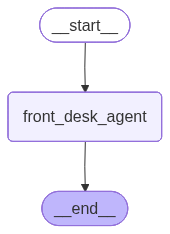

In [45]:
from IPython.display import Image
display(Image(FrontDeskWorkflow.get_graph(xray = True).draw_mermaid_png()))

### 4. Invoke FrontDeskWorkflow Agent Graph

In [46]:
initial_prompt = "You are Front Desk Administrator in an Hospital in the Netherlands. Start Verification of the following Patient:"

# let's the run the workflow
inputs = {'initial_prompt':initial_prompt}
output = FrontDeskWorkflow.invoke(inputs)
output 

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 15967.05it/s]


Gender Prediction using Pre-Trained Model : female


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 18663.75it/s]

Age Prediction to the Class: 20-29
Age Group Prediction: Minimum : 20 and Maximum: 29


{'initial_prompt': 'You are Front Desk Administrator in an Hospital in the Netherlands. Start Verification of the following Patient:',
 'messages': [],
 'patient_verification': 'Verification successfull.\n                                Patient is: Amrita Nair\n                                with ID : PAT1000000007 \n                                which is female in age group of 20-29 can proceed to the physician\n        '}

In [47]:
display(Markdown(output["patient_verification"]))

Verification successfull.
                                Patient is: Amrita Nair
                                with ID : PAT1000000007 
                                which is female in age group of 20-29 can proceed to the physician
        